In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict,List,Iterable,Any,Generator,Iterator
from option import Some, NONE, Option
from sklearn.datasets import make_blobs, make_classification
from sklearn.model_selection import train_test_split
import matplotlib.colors as mcolors
import numpy.typing as npt
import hashlib as H
import os
from scipy import stats
colors    = list(mcolors.cnames.items())

In [2]:
def k_generator(loc:int=0, scale:int=1):
    x = np.ceil(abs(stats.norm.rvs(loc = loc, scale = scale)))
    return int(x)

def interarrivalTime_generator():
    N = 1
    mean_arrival_rate      = 0.5
    mean_interarrival_time = 1/ mean_arrival_rate
    interarrival_times     = np.random.exponential(scale=mean_interarrival_time, size=N)
    return int(np.ceil(interarrival_times[0]))

In [3]:
def data_generator_clustering(records:int, attributes:int, centers:int):    
    features, target = make_blobs(
        n_samples   = records, # Cantidad de filas
        n_features  = attributes,  # Cantidad de columnas
        centers     = centers, # k 
        cluster_std = 0.02, # Modifica la separacion intra-cluster
        shuffle     = True, # Componnente aleatorio
        center_box  = (-1,1)
    )
    return features, target

def data_generator_classification(records:int, attributes:int, classes:int):
    max_info = max(1, attributes - 1)
    n_informative = min(2, max_info)
    X, y = make_classification(
        n_samples=records, 
        n_features=attributes, 
        n_informative=n_informative, # 2 
        n_redundant=0, 
        n_clusters_per_class=1, 
        n_classes=classes, 
        flip_y=0.01, 
        class_sep=1.5, 
        random_state=42
    )
    # model, data, model_labels, data_labels 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test
    

In [4]:
def trace_generator(experiment_id:str, task_id:str, algorithms:str, k:int="", dataset_id:str="", dataset_filename:str="", 
                    model_id:str="", model_filename:str="", model_labels_filename:str="", record_test_id:str="", record_test_filename:str="", avg_records:int=10, avg_attributes:int=1):
    extension         = "npy"
    threshold         = 0.004
    sens              = 0.000001
    max_iterations    = 3
    interarrival_time = interarrivalTime_generator()
    num_chunks        = 2
    
    rows = []
    for algorithm in algorithms:
        did = f"{dataset_id}_{algorithm}_{avg_records}_{avg_attributes}".lower()
        mid = f"{model_id}_{algorithm}_{avg_records}_{avg_attributes}".lower()
        row = [experiment_id, task_id, algorithm, did, dataset_filename, mid, model_filename, model_labels_filename, record_test_id, 
               record_test_filename, k, max_iterations, sens, threshold, interarrival_time, extension]
        rows.append(row)
    return rows

In [6]:
path           = '/home/sreyes/rory_analysis/rory_datasets/'
# original_trace = 'trace_experiment_sl128_pqc.csv'
original_trace = 'trace_experiment_schemes.csv'
read_trace     = pd.read_csv("{}/{}".format(path,original_trace))
trace_columns  = ["EXPERIMENT_ID","TASK_ID","ALGORITHM","DATASET_ID","DATASET_FILENAME","MODEL_ID","MODEL_FILENAME","MODEL_LABELS_FILENAME","RECORD_TEST_ID","RECORD_TEST_FILENAME",
                  "K","MAX_ITERATIONS","SENS","THRESHOLD","INTERARRIVAL_TIME","EXTENSION"]
clients       = 1
global_traces = {
    "CLUSTERING":{"KMEANS":[], "SKMEANS":[],"DBSKMEANS":[],"SKMEANSPQC":[],"DBSKMEANSPQC":[],"NNC":[],"DBSNNC":[]},
    "CLASSIFICATION":{"KNN":[], "SKNN":[], "SKNNPQC":[]},
    "SCHEMES":{"ENCRYPTION":[]}
}

for client in range(clients):
    for batch_index,y in read_trace.iterrows():
        experiment_id = y["EXPERIMENT_ID"] 
        datasets      = y["DATASETS"]
        task          = y["TASK"]
        traces        = global_traces[task]
        
        experiment_id  = 0
        for z in range(datasets):
            RECORDS = y["RECORDS"]
            ATTRS   = y["ATTRIBUTES"]   
            records     = int(abs(stats.norm.rvs(loc=RECORDS, scale=3)))
            _records    = records+1
            attributes  = int(abs(stats.norm.rvs(loc=ATTRS, scale=3)))
            _attributes = attributes+1 
            centers     = k_generator(loc = y["K"], scale = 1)
            while centers > _records:
                centers     = k_generator(loc = y["K"], scale = 1)
                
            dataset_id  = "{}C{}R{}A{}K{}".format(task,client,_records,_attributes, centers)
            dataset_id  = dataset_id.lower()
            
            folder_path  = "{}/{}C{}".format(path,task,client)
            dataset_path = "{}/datasets".format(folder_path)
            
            os.makedirs(folder_path,exist_ok=True) #Crea folder
#             # os.makedirs(batch_path,exist_ok=True)
            os.makedirs(dataset_path,exist_ok=True) #Crea folder
            
            if  task == "CLUSTERING":
                ALGORITHMS  = ["KMEANS","SKMEANS","DBSKMEANS","SKMEANSPQC","DBSKMEANSPQC","NNC","DBSNNC"]
                target_path = "{}/labels".format(folder_path)
                os.makedirs(target_path,exist_ok=True) #Crea folder
                
                target_id    = "{}LABELS".format(dataset_id)
                dataset_file = "{}/{}.npy".format(dataset_path,dataset_id)
                target_file  = "{}/{}.npy".format(target_path,target_id)
                
                dataset, target = data_generator_clustering(
                    records    = _records, 
                    attributes = _attributes, 
                    centers    = centers
                )
    
                np.save(dataset_file, dataset) #Guardar datasets
                np.save(target_file, target) #Guarda targets

                trace_chunk = trace_generator(
                    experiment_id    = experiment_id,
                    task_id          = task,
                    algorithms       = ALGORITHMS,
                    dataset_id       = dataset_id,
                    dataset_filename = dataset_id,
                    k                = centers,
                    avg_records      = RECORDS,
                    avg_attributes   = ATTRS
                )
                experiment_id += 1
                
            elif  task == "CLASSIFICATION":
                ALGORITHMS = ["KNN", "SKNN","SKNNPQC"]
                modelFilename       = "{}model".format(dataset_id)
                modelLabelsFilename = "{}modellabels".format(dataset_id)
                dataFilename        = "{}data".format(dataset_id)
                dataLabelsFilename  = "{}datalabels".format(dataset_id)

                modelPath           = "{}/{}.npy".format(dataset_path,modelFilename)
                modelLabelsPath     = "{}/{}.npy".format(dataset_path,modelLabelsFilename)
                dataPath            = "{}/{}.npy".format(dataset_path,dataFilename)
                dataLabelsPath      = "{}/{}.npy".format(dataset_path,dataLabelsFilename)
                print(_records,_attributes)
                model, data, model_labels, data_labels = data_generator_classification(
                    records    = _records, 
                    attributes = _attributes, 
                    classes    = 3,
                )
                np.save(modelPath, model) #Guarda modelo
                np.save(dataPath, data)   #Guarda dataset
                np.save(modelLabelsPath, model_labels) #Guarda etiquetas del modelo
                np.save(dataLabelsPath, data_labels)   #Guarda etiquetas del dataset
                
                trace_chunk = trace_generator(
                    experiment_id         = experiment_id,
                    task_id               = task,
                    algorithms            = ALGORITHMS,
                    model_id              = dataset_id,
                    model_filename        = modelFilename,
                    model_labels_filename = modelLabelsFilename,
                    record_test_id        = dataFilename,
                    record_test_filename  = dataFilename,
                    avg_records           = RECORDS,
                    avg_attributes        = ATTRS
                )
                experiment_id += 1

            if  task == "SCHEMES":
                ALGORITHMS  = ["ENCRYPTION"]
                target_path = "{}/labels".format(folder_path)
                os.makedirs(target_path,exist_ok=True) #Crea folder
                
                target_id    = "{}LABELS".format(dataset_id)
                dataset_file = "{}/{}.npy".format(dataset_path,dataset_id)
                target_file  = "{}/{}.npy".format(target_path,target_id)
                
                dataset, target = data_generator_clustering(
                    records    = _records, 
                    attributes = _attributes, 
                    centers    = centers
                )
    
                np.save(dataset_file, dataset) #Guardar datasets
                np.save(target_file, target) #Guarda targets

                trace_chunk = trace_generator(
                    experiment_id    = experiment_id,
                    task_id          = task,
                    algorithms       = ALGORITHMS,
                    dataset_id       = dataset_id,
                    dataset_filename = dataset_id,
                    k                = centers,
                    avg_records      = RECORDS,
                    avg_attributes   = ATTRS
                )
                experiment_id += 1

            for index,trace_row in enumerate(trace_chunk):
                traces[ALGORITHMS[index]].append(trace_row)
            
            for algorithm, trace in traces.items():
                trace_path = "{}/{}.csv".format(folder_path,algorithm)
                    
                trace_df = pd.DataFrame(trace, columns=trace_columns)
                trace_df.to_csv(trace_path, index=False)
       

Tamaño en bytes =  número de muestras x número de características x tamaño en bytes del tipo de datos

100,000 x 10 x 8 bytes = 8,000,000 bytes

Lo que equivale a aproximadamente:

8,000,000bytes / (1024 x 1024) = 7.63 MB

In [ ]:
for i in range(50):
    N = 50
    mean_arrival_rate      = 0.5
    mean_interarrival_time = 1/ mean_arrival_rate
    interarrival_times     = np.random.exponential(scale=mean_interarrival_time, size=N)
    interarrival_times = interarrival_times
interarrival_times

In [ ]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

# Generar un conjunto de datos sintético con 3 clases
X, y = make_classification(
    n_samples=100, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_clusters_per_class=1, 
    n_classes=3, 
    flip_y=0.01, 
    class_sep=1.5, 
    random_state=42)

# Visualizar el conjunto de datos generado
plt.scatter(X[:, 0], X[:, 1], marker='o', c=y, s=25, edgecolor='k', cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Visualización del Conjunto de Datos Generado con 3 Clases')
plt.show()



<Axes: xlabel='INTERARRIVAL_TIME', ylabel='Count'>

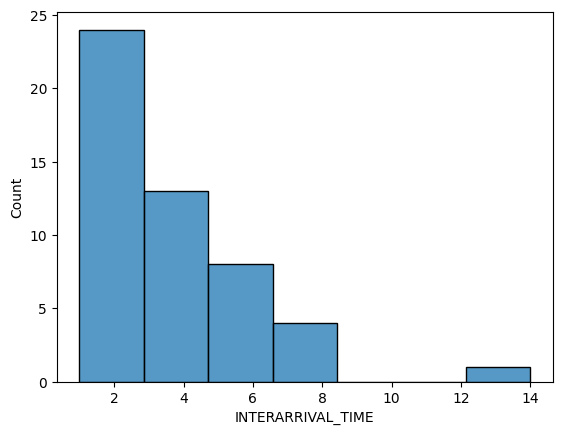

In [40]:
sns.histplot(data=trace_df["INTERARRIVAL_TIME"])